### 1.1 Datenabruf und Filterung

In [1]:
# Stationsmetadaten und gueltige Tageswerte zusammenfuehren

from wetterdienst import Settings
from wetterdienst.provider.dwd.observation import DwdObservationRequest
import pandas as pd

# Cache aktiv lassen, damit wiederholte Abfragen schneller sind
settings = Settings(cache_disable=False)

date = "2026-04-17"
station_mode = "limit"  # "all" oder "limit"
station_limit = 200

request = DwdObservationRequest(
    parameters=("daily", "climate_summary", "temperature_air_mean_2m"),
    start_date=date,
    end_date=date,
    settings=settings,
)

# Stationen je nach Modus: alle oder limitiert
all_stations = request.all().df.to_pandas()
all_station_ids = all_stations["station_id"].drop_duplicates().tolist()
if station_mode == "all":
    selected_station_ids = all_station_ids
else:
    selected_station_ids = all_station_ids[:station_limit]

print(f"Modus: {station_mode} | Verwendete Stationen: {len(selected_station_ids)}")

stations_manager = request.filter_by_station_id(selected_station_ids)

stations = stations_manager.df.to_pandas()
values = stations_manager.values.all().df.to_pandas()

values["value"] = pd.to_numeric(values["value"], errors="coerce")

stations_with_data = stations.merge(
    values.loc[values["value"].notna(), ["station_id", "value"]],
    on="station_id",
    how="inner",
)

print("Anzahl Stationen mit gueltigem Wert:", len(stations_with_data))
stations_with_data

Modus: limit | Verwendete Stationen: 200
Anzahl Stationen mit gueltigem Wert: 181


,resolution,dataset,station_id,start_date,end_date,latitude,longitude,height,name,state,value
0,daily,climate_summary,00044,1969-01-01 00:00:00+00:00,2026-04-17 00:00:00+00:00,52.9336,8.2370,44.0,Großenkneten,Niedersachsen,13.8
1,daily,climate_summary,00073,1959-03-01 00:00:00+00:00,2026-04-17 00:00:00+00:00,48.6183,13.0620,374.0,Aldersbach-Kramersepp,Bayern,13.6
2,daily,climate_summary,00078,1961-01-01 00:00:00+00:00,2026-04-17 00:00:00+00:00,52.4853,7.9125,64.0,Alfhausen,Niedersachsen,13.5
3,daily,climate_summary,00091,1978-11-01 00:00:00+00:00,2026-04-17 00:00:00+00:00,50.7446,9.3450,304.0,Alsfeld-Eifa,Hessen,13.8
4,daily,climate_summary,00096,2019-04-09 00:00:00+00:00,2026-04-17 00:00:00+00:00,52.9437,12.8518,50.0,Neuruppin-Alt Ruppin,Brandenburg,12.6
...,...,...,...,...,...,...,...,...,...,...,...
176,daily,climate_summary,02597,1946-01-01 00:00:00+00:00,2026-04-17 00:00:00+00:00,50.2240,10.0792,282.0,"Kissingen, Bad",Bayern,13.9
177,daily,climate_summary,02600,1982-11-01 00:00:00+00:00,2026-04-17 00:00:00+00:00,49.7363,10.1781,193.0,Kitzingen,Bayern,14.4
178,daily,climate_summary,02601,1936-01-01 00:00:00+00:00,2026-04-17 00:00:00+00:00,50.2218,8.4469,822.0,Kleiner Feldberg/Taunus,Hessen,13.6
179,daily,climate_summary,02618,1958-01-01 00:00:00+00:00,2026-04-17 00:00:00+00:00,50.8458,10.4803,732.0,Kleiner Inselsberg,Thüringen,12.3


### 1.2 Deutschland laden & Daten projezieren

In [5]:
# Deutschland laden und Stationen projizieren

import json
import numpy as np
from pyproj import Transformer

with open("de.json", encoding="utf-8") as fh:
    geo = json.load(fh)

polygons = geo["features"][0]["geometry"]["coordinates"]
ring = np.asarray(polygons[0][0], dtype=float)

transformer = Transformer.from_crs("EPSG:4326", "EPSG:3035", always_xy=True)

gx, gy = transformer.transform(ring[:, 0], ring[:, 1])
boundary_xy = np.column_stack([gx, gy])

sx, sy = transformer.transform(
    stations_with_data["longitude"].to_numpy(),
    stations_with_data["latitude"].to_numpy(),
)

stations_with_data = stations_with_data.copy()
stations_with_data["x"] = sx
stations_with_data["y"] = sy


In [6]:
# Zielraster und Maskierung vorbereiten

from matplotlib.path import Path

country_path = Path(boundary_xy)

min_x, min_y = boundary_xy.min(axis=0)
max_x, max_y = boundary_xy.max(axis=0)

grid_x, grid_y = np.meshgrid(
    np.linspace(min_x, max_x, 140),
    np.linspace(min_y, max_y, 170),
)

targets = np.column_stack([grid_x.ravel(), grid_y.ravel()])
inside_mask = country_path.contains_points(targets).reshape(grid_x.shape)


In [7]:
# PyKrige auf projizierten Stationspunkten und Zielachsen ausführen

from pykrige.ok import OrdinaryKriging

ok = OrdinaryKriging(
    x=stations_with_data["x"].to_numpy(),
    y=stations_with_data["y"].to_numpy(),
    z=stations_with_data["value"].to_numpy(),
    variogram_model="spherical",
    coordinates_type="euclidean",
)

z_pred, z_var = ok.execute(
    "grid",
    np.linspace(min_x, max_x, 140),
    np.linspace(min_y, max_y, 170),
)

z_pred = np.where(inside_mask, np.asarray(z_pred, dtype=float), np.nan)
z_var = np.where(inside_mask, np.asarray(z_var, dtype=float), np.nan)


In [9]:
# Historische Reihe bis Ende 2025 auf Monatsmittel bringen

from statsmodels.tsa.seasonal import STL

station = DwdObservationRequest(
    parameters=("daily", "climate_summary", "temperature_air_mean_2m"),
    start_date="1880-01-01",
    end_date="2025-12-31",
    settings=settings,
).filter_by_name(name="Chemnitz")

values = station.values.all().df.to_pandas()
values["date"] = pd.to_datetime(values["date"], utc=True)
values["value"] = pd.to_numeric(values["value"], errors="coerce")

monthly = (
    values.dropna(subset=["value"])
    .set_index("date")["value"]
    .resample("ME")
    .mean()
)

stl = STL(monthly, period=12, robust=True).fit()


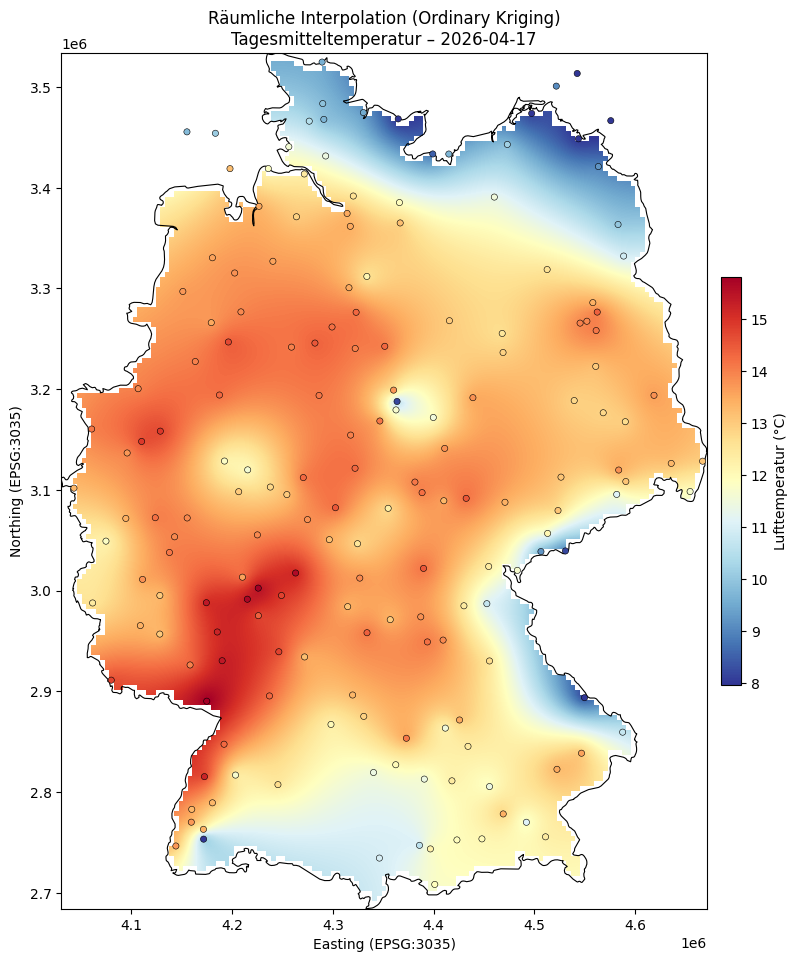

In [12]:
# Interpolationskarte visualisieren

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 10))

img = ax.imshow(
    z_pred,
    extent=[min_x, max_x, min_y, max_y],
    origin="lower",
    cmap="RdYlBu_r",
    interpolation="bilinear",
)

ax.plot(boundary_xy[:, 0], boundary_xy[:, 1], color="black", linewidth=0.8)

ax.scatter(
    stations_with_data["x"],
    stations_with_data["y"],
    c=stations_with_data["value"],
    cmap="RdYlBu_r",
    edgecolors="black",
    linewidths=0.4,
    s=20,
    zorder=5,
    norm=img.norm,
)

cbar = fig.colorbar(img, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Lufttemperatur (°C)")

ax.set_title(f"Räumliche Interpolation (Ordinary Kriging)\nTagesmitteltemperatur – {date}", fontsize=12)
ax.set_xlabel("Easting (EPSG:3035)")
ax.set_ylabel("Northing (EPSG:3035)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()
